In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [96]:
plasma = pd.read_csv(r"Data\93p2mTorr_0.36kV_50A_spectrum_data.csv")
background = pd.read_csv(r"Data\background.csv")


In [97]:
plasma.head()

,Wavelength_nm,Intensity
0,317.779,0.035541
1,318.882,0.026841
2,319.985,0.032686
3,321.088,0.026591
4,322.191,0.032922


In [98]:
background.head()

,Wavelength_nm,Intensity
0,317.779,0.0
1,318.882,0.0
2,319.985,0.0
3,321.088,0.0
4,322.191,0.0


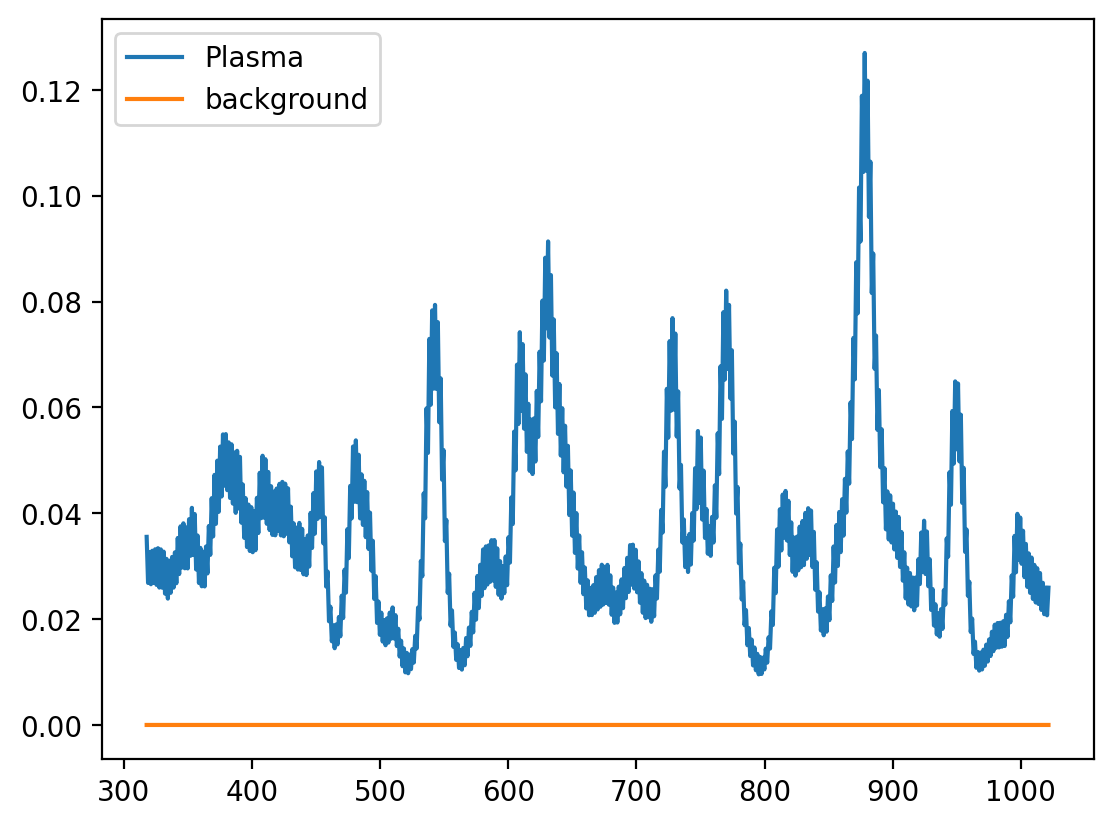

In [99]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], plasma['Intensity'], label='Plasma')
plt.plot(background['Wavelength_nm'], background['Intensity'], label='background')
plt.legend()

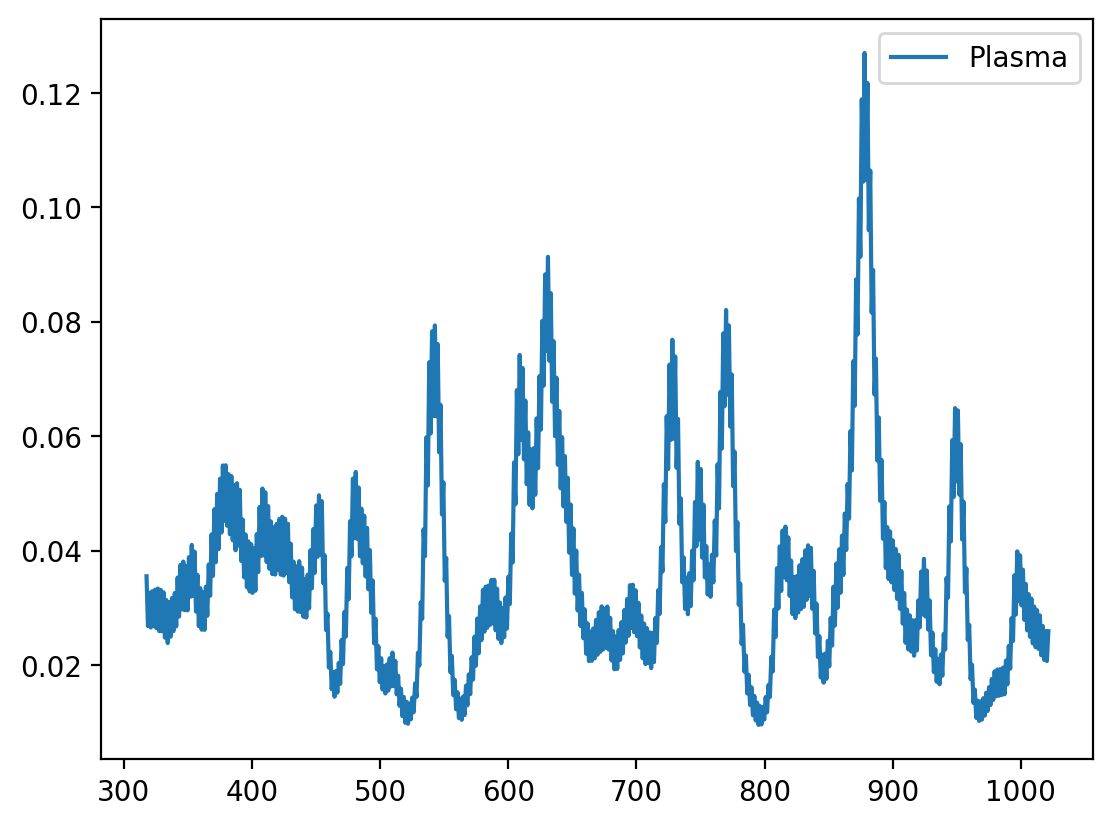

In [100]:
plt.figure(dpi=200)
plt.plot(plasma['Wavelength_nm'], (plasma['Intensity']-background['Intensity']).clip(lower=0), label='Plasma')
plt.legend()

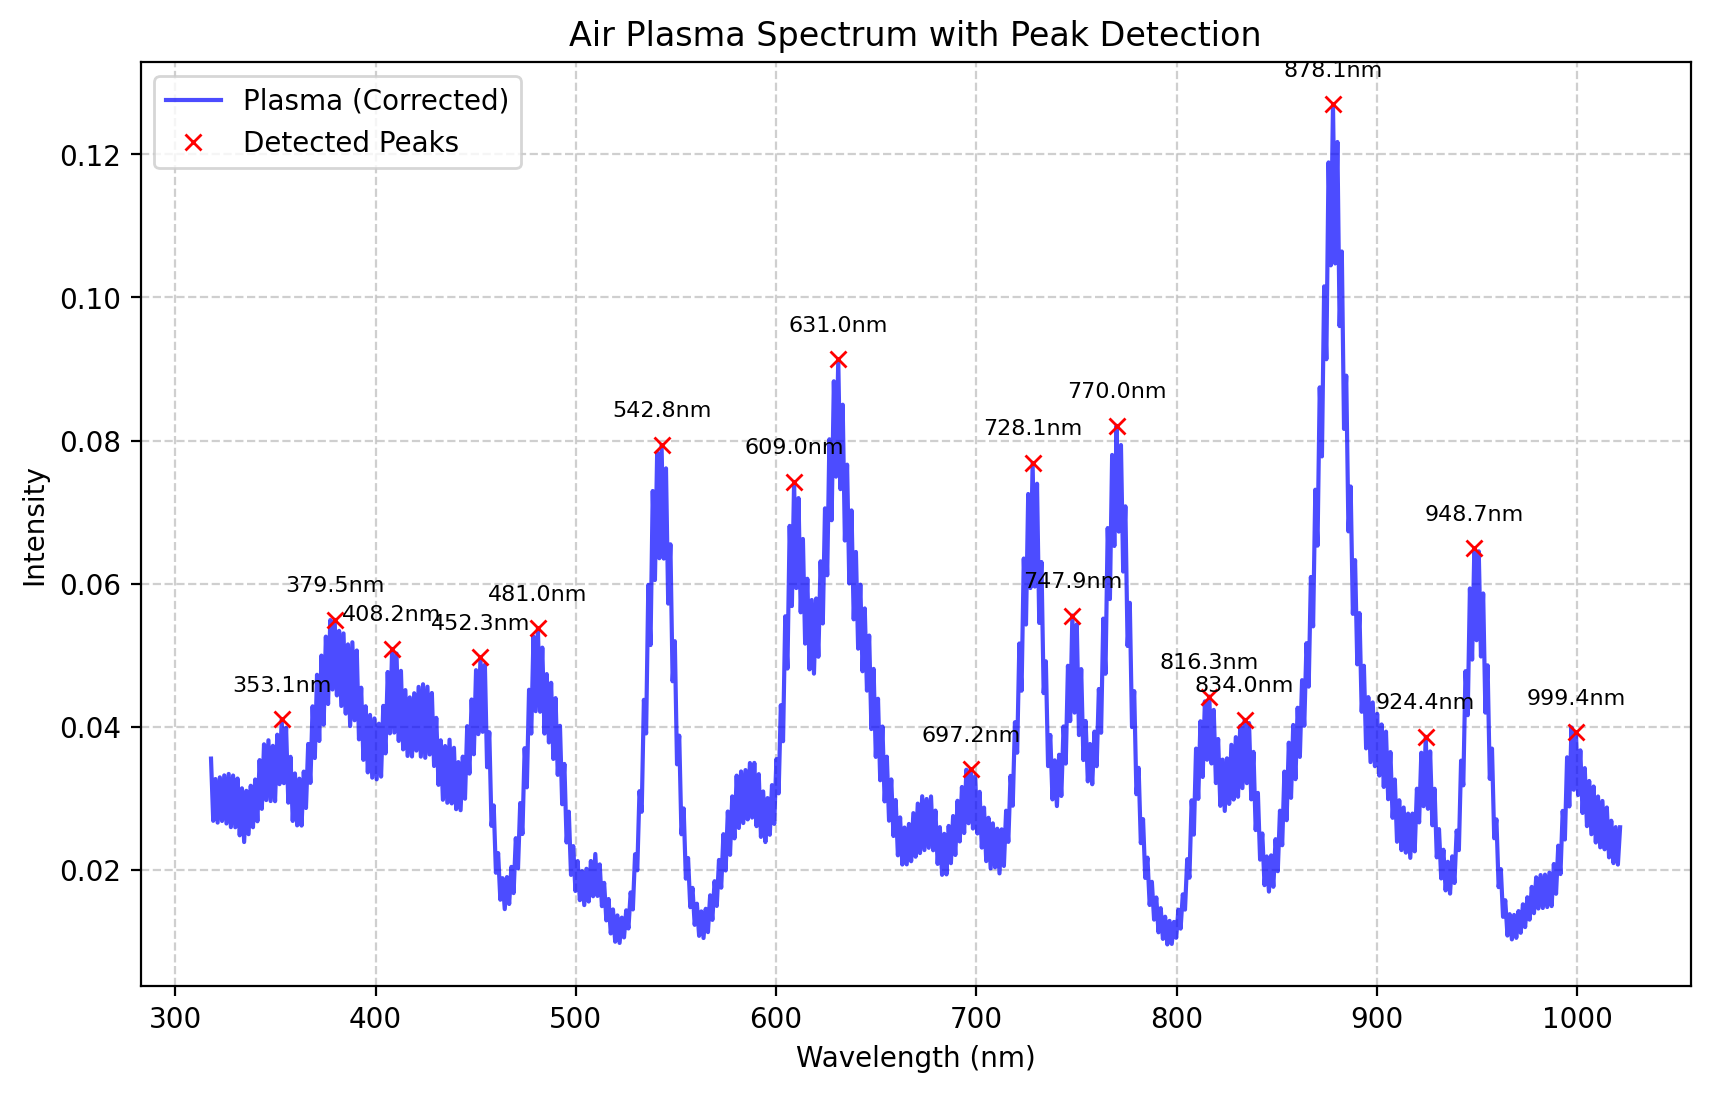

   Target_nm   Actual_nm  Amplitude      Sigma    FWHM_nm  Integrated_Area
0        380  380.508329   0.016002   9.003685  21.202059         0.361144
1        481  482.696872   0.052116  10.738156  25.286425         1.402785
2        630  630.779020   0.029644   4.589406  10.807226         0.341025
3        725  727.994181   0.044465   5.366938  12.638173         0.598190
4        770  770.196518   0.044729   5.132022  12.084988         0.575402
5        880  878.313755   0.065124   5.189173  12.219569         0.847090
6        950  949.864971   0.044713   5.570645  13.117867         0.624350
{'r1': np.float64(1.5932733442285345), 'r2': np.float64(0.6038630391874568), 'r4': np.float64(0.9619050504547917), 'r5': np.float64(1.8308050171281218), 'w630': np.float64(10.807226215593964), 'w880': np.float64(12.21956867685376)}


In [101]:
from scipy.signal import find_peaks,peak_widths, savgol_filter
from scipy.optimize import curve_fit

# 1. Calculate the corrected intensity
# We clip at 0 because negative intensity values (noise) don't represent a signal
corrected_intensity = (plasma['Intensity'] - background['Intensity']).clip(lower=0)
wavelengths = plasma['Wavelength_nm']

# 2. Find the peaks
# 'prominence' is key: it ignores small ripples/noise. 
# Adjust 'prominence' based on your signal-to-noise ratio.
peaks, properties = find_clean_peaks(corrected_intensity)

# 3. Plotting
plt.figure(figsize=(10, 6), dpi=200)
plt.plot(wavelengths, corrected_intensity, label='Plasma (Corrected)', color='blue', alpha=0.7)

# Plot the identified peaks
plt.plot(wavelengths.iloc[peaks], corrected_intensity.iloc[peaks], "x", color='red', label='Detected Peaks')

# Optional: Annotate the peaks with their wavelength
for i in peaks:
    plt.annotate(f"{wavelengths.iloc[i]:.1f}nm", 
                 (wavelengths.iloc[i], corrected_intensity.iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Air Plasma Spectrum with Peak Detection')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C

def find_clean_peaks(intensity):
    intensity_smooth = savgol_filter(intensity, 11, 3)

    noise_level = np.std(intensity_smooth[:100])
    prominence = 0.8 * noise_level

    peaks, props = find_peaks(
        intensity_smooth,
        prominence=prominence,
        distance=10,
        width=3
    )

    return peaks, props

def analyze_specific_peaks(df, targets, window=15, fit_window=10):
    """
    Finds specific peaks, returns heights and FWHM in nm.
    """
    # wavelengths = df['Wavelength_nm'].values
    # intensity = (df['Intensity'])# - background['Intensity']).clip(lower=0).values
    # prominence = max(intensity)*0.1
    
    # nm_per_pixel = np.mean(np.diff(wavelengths))

    # peaks, props = find_peaks(intensity, prominence=prominence)

    # widths_indices = peak_widths(intensity, peaks, rel_height=0.5)[0]

    # results = []

    # for target in targets:
    #     diffs = np.abs(wavelengths[peaks] - target)
    #     closest_idx = np.argmin(diffs)
        
    #     if diffs[closest_idx] <= window:
    #         p_idx = peaks[closest_idx]
    #         actual_wl = wavelengths[p_idx]
    #         height = intensity[p_idx]
            
    #         fwhm_nm = widths_indices[closest_idx] * nm_per_pixel


    #         results.append({
    #             "Target_nm": target,
    #             "Actual_nm": actual_wl,
    #             "Height": height,
    #             "FWHM_nm": fwhm_nm
    #         })
    #     else:
    #         results.append({
    #             "Target_nm": target,
    #             "Actual_nm": "Not Found",
    #             "Height": 0,
    #             "FWHM_nm": 0
    #         })

    # return pd.DataFrame(results)
    wavelengths = df['Wavelength_nm'].values
    intensity = df['Intensity'].values

    #prominence = max(intensity) * 0.1
    peaks, props = find_clean_peaks(intensity)#, prominence=prominence)

    results = []

    for target in targets:
        diffs = np.abs(wavelengths[peaks] - target)
        closest_idx = np.argmin(diffs)

        if diffs[closest_idx] <= window:
            p_idx = peaks[closest_idx]

            # Define local fitting window
            left = max(0, p_idx - fit_window)
            right = min(len(wavelengths), p_idx + fit_window)

            x_fit = wavelengths[left:right]
            y_fit = intensity[left:right]

            # Initial guesses
            A0 = np.max(y_fit)
            mu0 = wavelengths[p_idx]
            sigma0 = (x_fit[-1] - x_fit[0]) / 6  # rough guess
            C0 = np.min(y_fit)

            try:
                popt, _ = curve_fit(
                    gaussian, x_fit, y_fit,
                    p0=[A0, mu0, sigma0, C0]
                )

                A, mu, sigma, C = popt

                # Integrated area of Gaussian (excluding baseline)
                area = A * sigma * np.sqrt(2 * np.pi)

                # FWHM from sigma
                fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma

                results.append({
                    "Target_nm": target,
                    "Actual_nm": mu,
                    "Amplitude": A,
                    "Sigma": sigma,
                    "FWHM_nm": fwhm,
                    "Integrated_Area": area
                })

            except RuntimeError:
                # Fit failed
                results.append({
                    "Target_nm": target,
                    "Actual_nm": "Fit Failed",
                    "Amplitude": 0,
                    "Sigma": 0,
                    "FWHM_nm": 0,
                    "Integrated_Area": 0
                })

        else:
            results.append({
                "Target_nm": target,
                "Actual_nm": "Not Found",
                "Amplitude": 0,
                "Sigma": 0,
                "FWHM_nm": 0,
                "Integrated_Area": 0
            })

    return pd.DataFrame(results)

target_list = [380,481,630,725,770, 880, 950]
peak_data = analyze_specific_peaks(plasma, target_list)

print(peak_data)

# def peak_ratios(peak_data):
#     pk1 = peak_data.loc[peak_data['Target_nm'] == 380, 'Height'].values[0]
#     pk2 = peak_data.loc[peak_data['Target_nm'] == 481, 'Height'].values[0]
#     pk3 = peak_data.loc[peak_data['Target_nm'] == 630, 'Height'].values[0]
#     pk4 = peak_data.loc[peak_data['Target_nm'] == 725, 'Height'].values[0]
#     pk5 = peak_data.loc[peak_data['Target_nm'] == 770, 'Height'].values[0]
#     pk6 = peak_data.loc[peak_data['Target_nm'] == 880, 'Height'].values[0]
#     pk7 = peak_data.loc[peak_data['Target_nm'] == 950, 'Height'].values[0]
#     ratio1 = pk5 / pk1 if (pk1 and pk5)  != 0 else np.nan
#     ratio2 = pk6/pk2 if (pk2 and pk6) != 0 else np.nan
#     ratio3 = pk2/pk1 if (pk1 and pk2) != 0 else np.nan
#     ratio4 = pk5/pk4 if (pk4 and pk5) != 0 else np.nan
#     ratio5= pk7/pk3 if (pk3 and pk7) != 0 else np.nan
#     return {
#         "r1": ratio1,
#         "r2": ratio2,
#         "r3": ratio3,
#         "r4": ratio4,
#         "r5": ratio5,
#         "r6": np.nan
#     }

def peak_ratios(peak_data):
    def get_val(wl, col):
        vals = peak_data.loc[peak_data['Target_nm'] == wl, col].values
        return vals[0] if len(vals) > 0 else np.nan

    # Heights (or Integrated_Area if you switched earlier — recommended)
    pk1 = get_val(380, 'Integrated_Area')
    pk2 = get_val(481, 'Integrated_Area')
    pk3 = get_val(630, 'Integrated_Area')
    pk4 = get_val(725, 'Integrated_Area')
    pk5 = get_val(770, 'Integrated_Area')
    pk6 = get_val(880, 'Integrated_Area')
    pk7 = get_val(950, 'Integrated_Area')

    # Widths (FWHM)
    w630 = get_val(630, 'FWHM_nm')
    w880 = get_val(880, 'FWHM_nm')

    # Safe division helper
    def safe_div(a, b):
        return a / b if (b not in [0, np.nan] and not np.isnan(b)) else np.nan

    ratio1 = safe_div(pk5, pk1)
    ratio2 = safe_div(pk6, pk2)
    # ratio3 REMOVED
    ratio4 = safe_div(pk5, pk4)
    ratio5 = safe_div(pk7, pk3)

    return {
        "r1": ratio1,
        "r2": ratio2,
        "r4": ratio4,
        "r5": ratio5,
        "w630": w630,
        "w880": w880
    }

# def peak_ratios(peak_data):
#     pk1 = peak_data.loc[peak_data['Target_nm'] == 380, 'Height'].values[0]
#     pk2 = peak_data.loc[peak_data['Target_nm'] == 481, 'Height'].values[0]
#     pk3 = peak_data.loc[peak_data['Target_nm'] == 630, 'Height'].values[0]
#     pk4 = peak_data.loc[peak_data['Target_nm'] == 725, 'Height'].values[0]
#     pk5 = peak_data.loc[peak_data['Target_nm'] == 770, 'Height'].values[0]
#     pk6 = peak_data.loc[peak_data['Target_nm'] == 880, 'Height'].values[0]
#     pk7 = peak_data.loc[peak_data['Target_nm'] == 950, 'Height'].values[0]
#     ratio1 = pk1 / pk6 if pk6 != 0 else np.nan
#     ratio2 = pk2/pk6 if pk6 != 0 else np.nan
#     ratio3 = pk3/pk6 if pk6 != 0 else np.nan
#     ratio4 = pk4/pk6 if pk6 != 0 else np.nan
#     ratio5= pk5/pk6 if pk6 != 0 else np.nan
#     ratio6 = pk7/pk6 if pk6 != 0 else np.nan

    
#     return {
#         "r1": ratio1,
#         "r2": ratio2,
#         "r3": ratio3,
#         "r4": ratio4,
#         "r5": ratio5,
#         'r6':ratio6

#     }

ratios = peak_ratios(peak_data)
print(ratios)

In [102]:
import os
import re

folder_path = './Data/'  # Change this to the path where your CSVs are stored

all_results = []

print(f"{'File':<40} | {'Press':<8} | {'kV':<6} | {'Amps':<5}")
print("-" * 75)

for filename in os.listdir(folder_path):
    if filename.endswith(".csv") and "_spectrum_data" in filename:
        # 1. Parse Filename (Extract 15.7, 0.48, 60)
        # Pattern looks for numbers followed by units
        try:
            pressure = re.search(r'([\dpt]+)mTorr', filename).group(1).replace('p', '.')
            voltage = re.search(r'([\dpt]+)kV', filename).group(1).replace('p', '.')
            current = re.search(r'([\dpt]+)A', filename).group(1).replace('p', '.')
        except AttributeError:
            continue # Skip files that don't match the naming convention

        # 2. Load File
        file_path = os.path.join(folder_path, filename)
        print(file_path)
        plasma = pd.read_csv(file_path)

        # 3. Analyze
        peak_results = analyze_specific_peaks(plasma, target_list, window=15)
        rat_results = peak_ratios(peak_results)

        # 4. Store Data
        row = {
            'File': filename,
            'Pressure_mTorr': float(pressure),
            'Voltage_kV': float(voltage),
            'Current_A': float(current),
            'rat1': rat_results['r1'],
            'rat2': rat_results['r2'],
            #'rat3': rat_results['r3'],
            'rat4': rat_results['r4'],
            'rat5': rat_results['r5'],
            'w630': rat_results['w630'],
            'w880': rat_results['w880']
        }
        
            
        all_results.append(row)
        print(f"{filename[:38]:<40} | {pressure:<8} | {voltage:<6} | {current:<5}")

# 5. Create Master Summary DataFrame
summary_df = pd.DataFrame(all_results)
summary_df.to_csv("experiment_summary_norm.csv", index=False)
print("\nBatch processing complete. Summary saved to 'experiment_summary_norm.csv'.")

File                                     | Press    | kV     | Amps 
---------------------------------------------------------------------------
./Data/50p2mTorr_0.38kV_70A_spectrum_data.csv
50p2mTorr_0.38kV_70A_spectrum_data.csv   | 50.2     | 38     | 70   
./Data/24p6mTorr_0.46kV_40A_spectrum_data.csv
24p6mTorr_0.46kV_40A_spectrum_data.csv   | 24.6     | 46     | 40   
./Data/36p0mTorr_0.47kV_60A_spectrum_data.csv
36p0mTorr_0.47kV_60A_spectrum_data.csv   | 36.0     | 47     | 60   
./Data/20p0mTorr_0.50kV_70A_spectrum_data.csv
20p0mTorr_0.50kV_70A_spectrum_data.csv   | 20.0     | 50     | 70   
./Data/106mTorr_0.36kV_10A_spectrum_data.csv
106mTorr_0.36kV_10A_spectrum_data.csv    | 106      | 36     | 10   
./Data/24p7mTorr_0.47kV_60A_spectrum_data.csv
24p7mTorr_0.47kV_60A_spectrum_data.csv   | 24.7     | 47     | 60   
./Data/16p1mTorr_0.49kV_70A_spectrum_data.csv
16p1mTorr_0.49kV_70A_spectrum_data.csv   | 16.1     | 49     | 70   
./Data/49p9mTorr_0.38kV_20A_spectrum_data.csv
49p9m

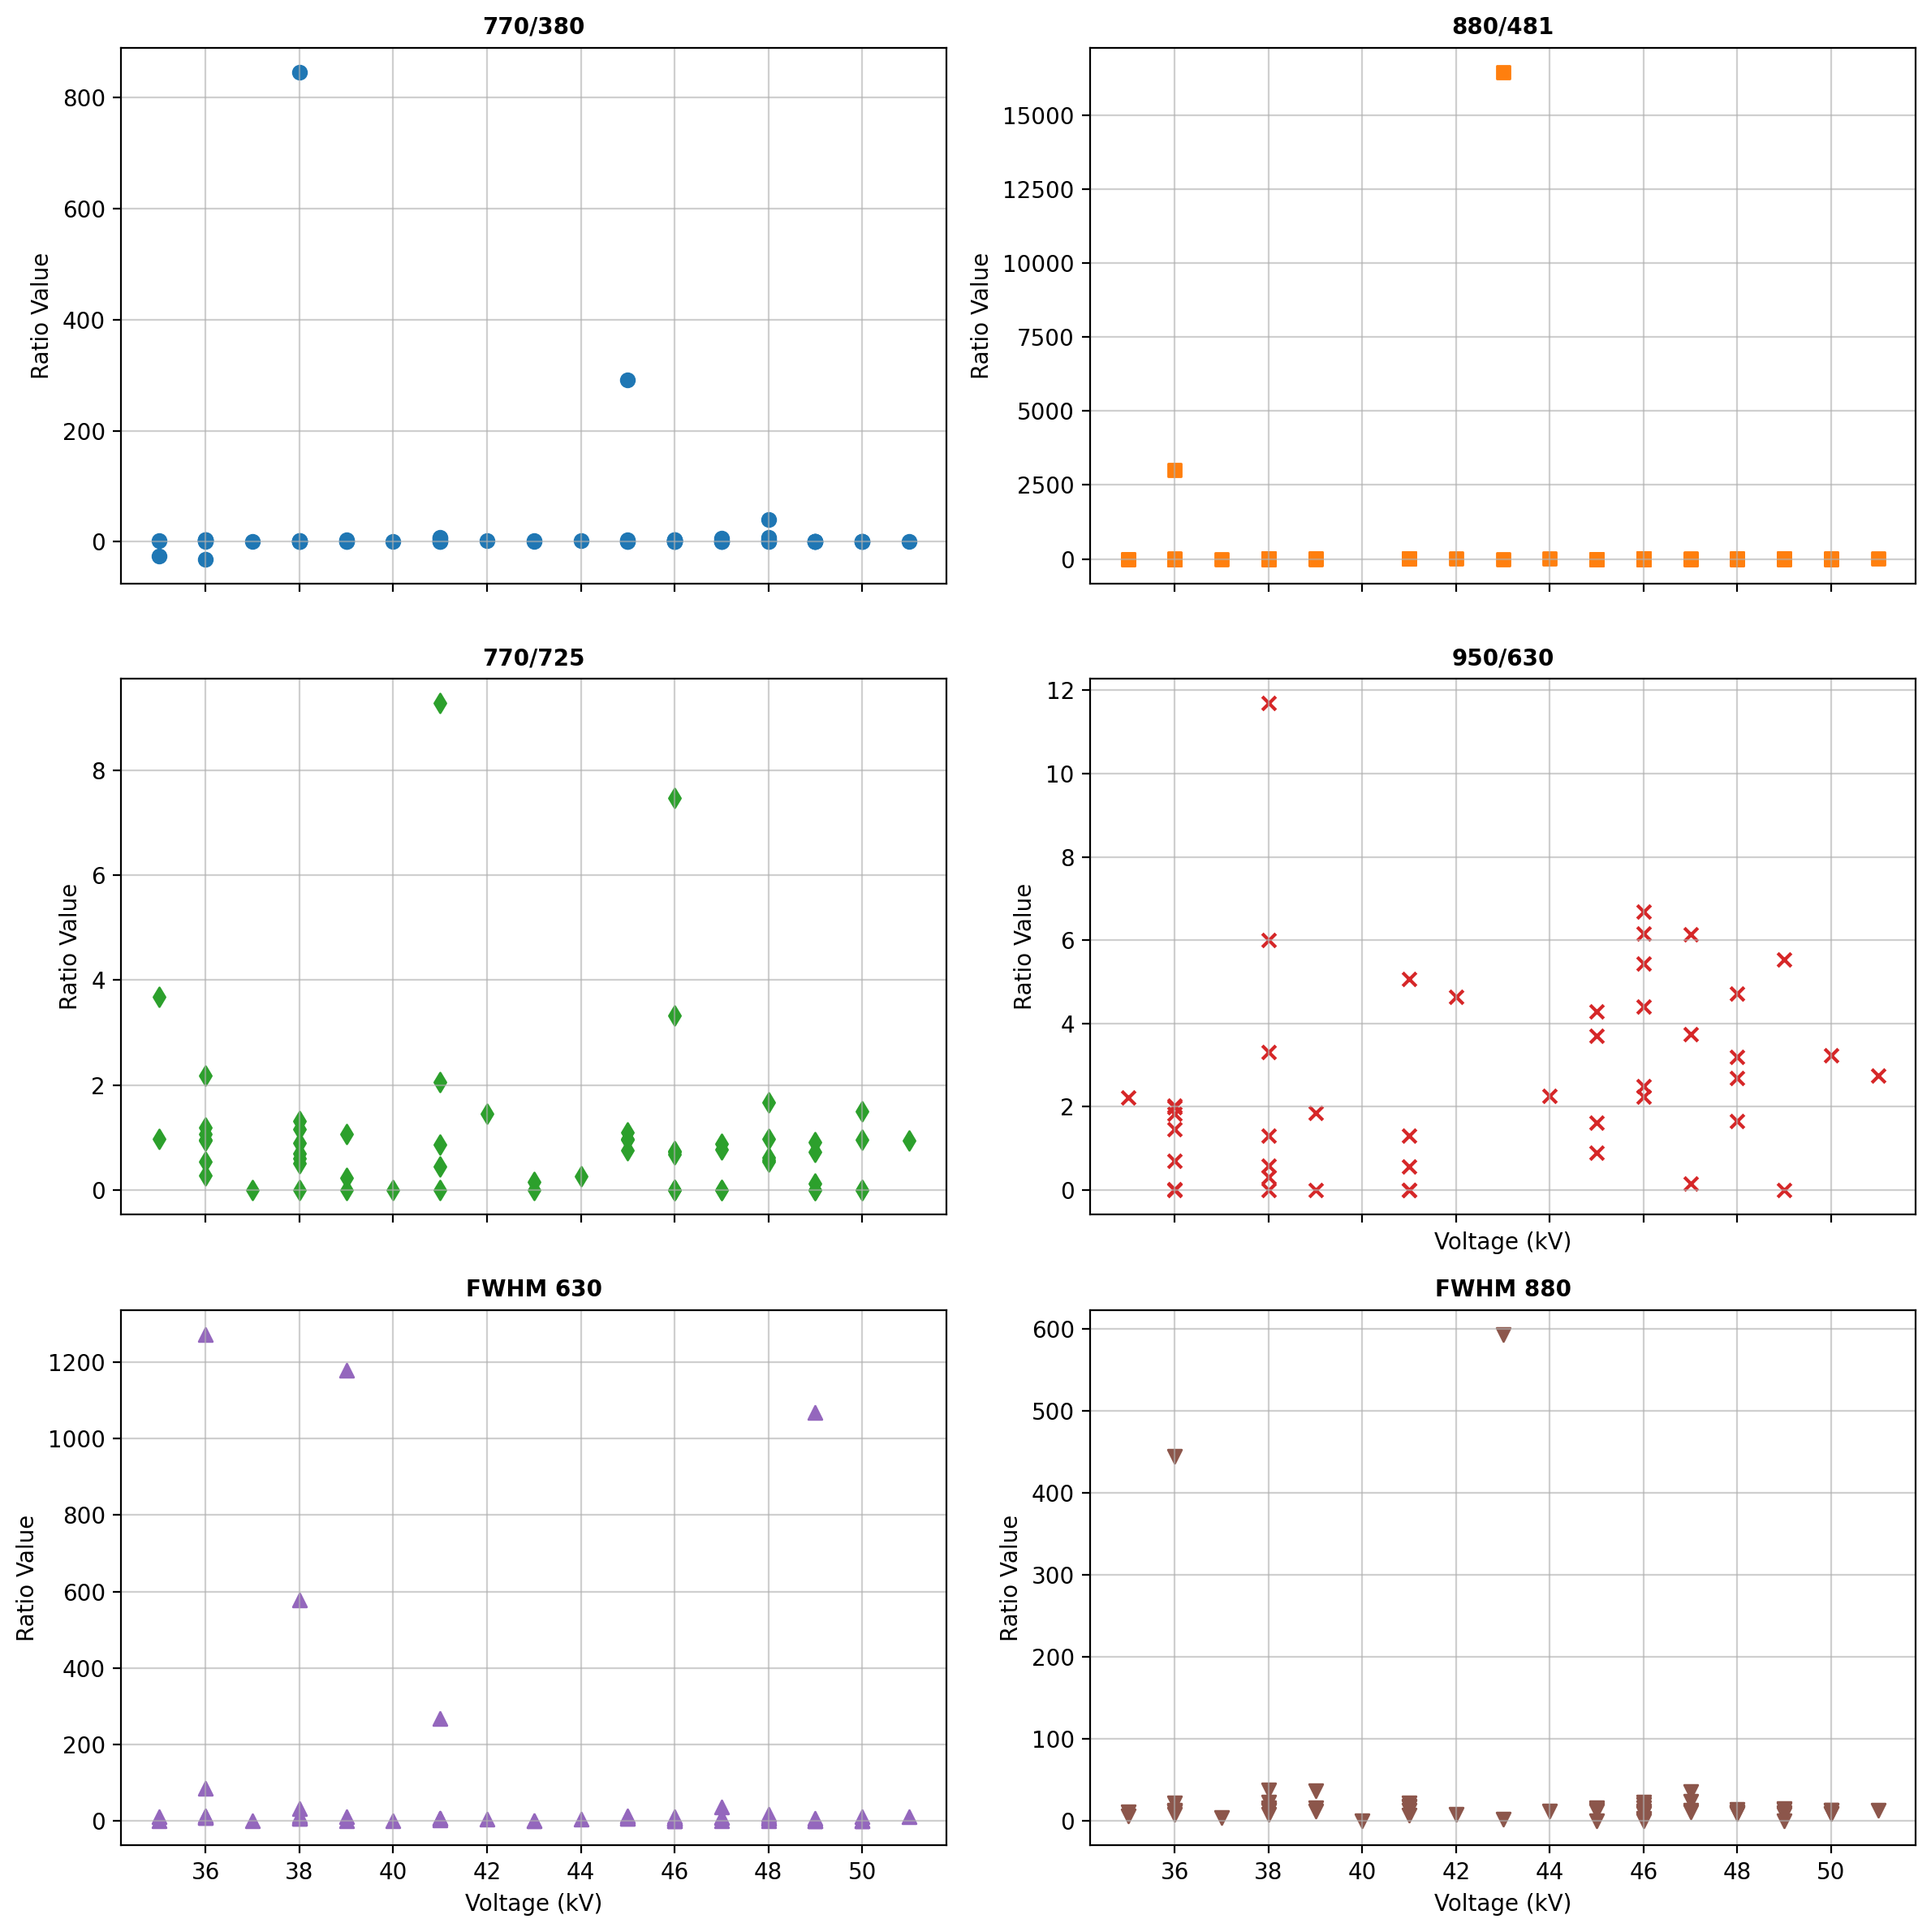

In [103]:

# 1. Sort the data first to ensure lines connect correctly
summary_df = summary_df.sort_values(by='Voltage_kV')

# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat4', 'rat5', 'w630', 'w880']
labels = ['770/380', '880/481', '770/725', '950/630', 'FWHM 630', 'FWHM 880']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Voltage_kV'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Voltage (kV)')


plt.tight_layout()
plt.show()

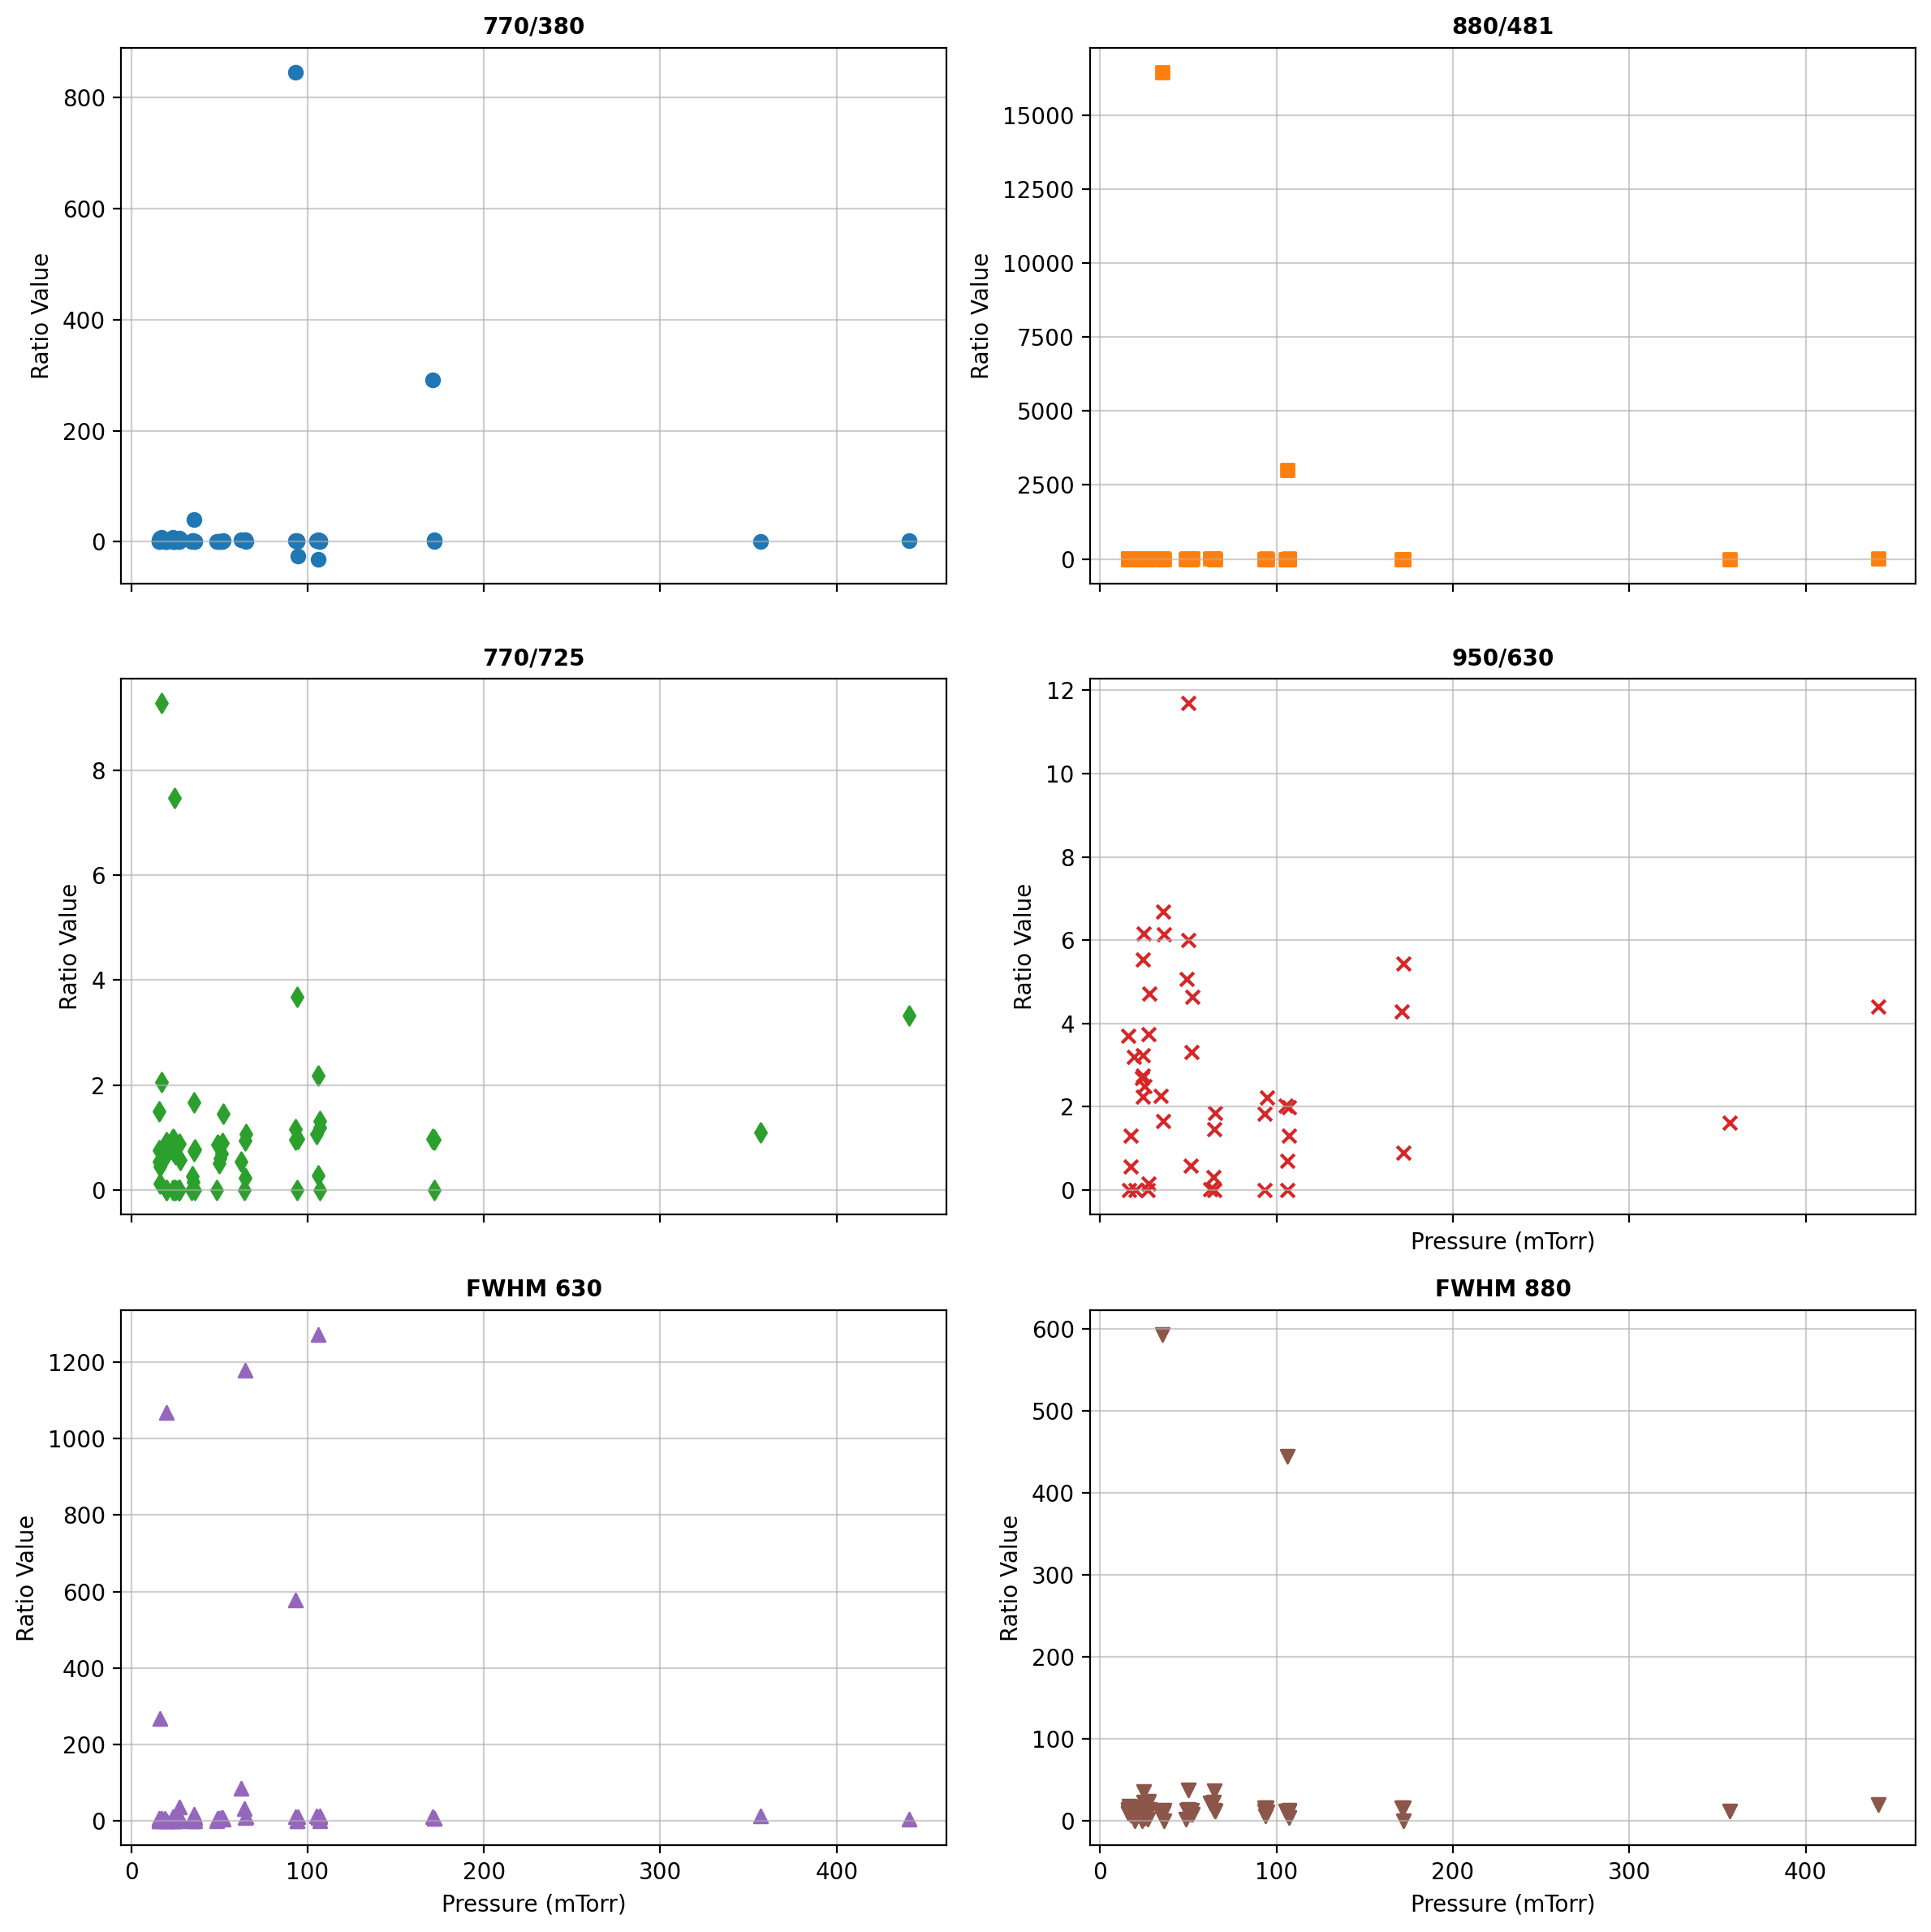

In [104]:

# 1. Sort the data first to ensure lines connect correctly
summary_df = summary_df.sort_values(by='Pressure_mTorr')

# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat4', 'rat5', 'w630', 'w880']
labels = ['770/380', '880/481', '770/725', '950/630', 'FWHM 630', 'FWHM 880']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Pressure_mTorr'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Pressure (mTorr)')


plt.tight_layout()
plt.show()

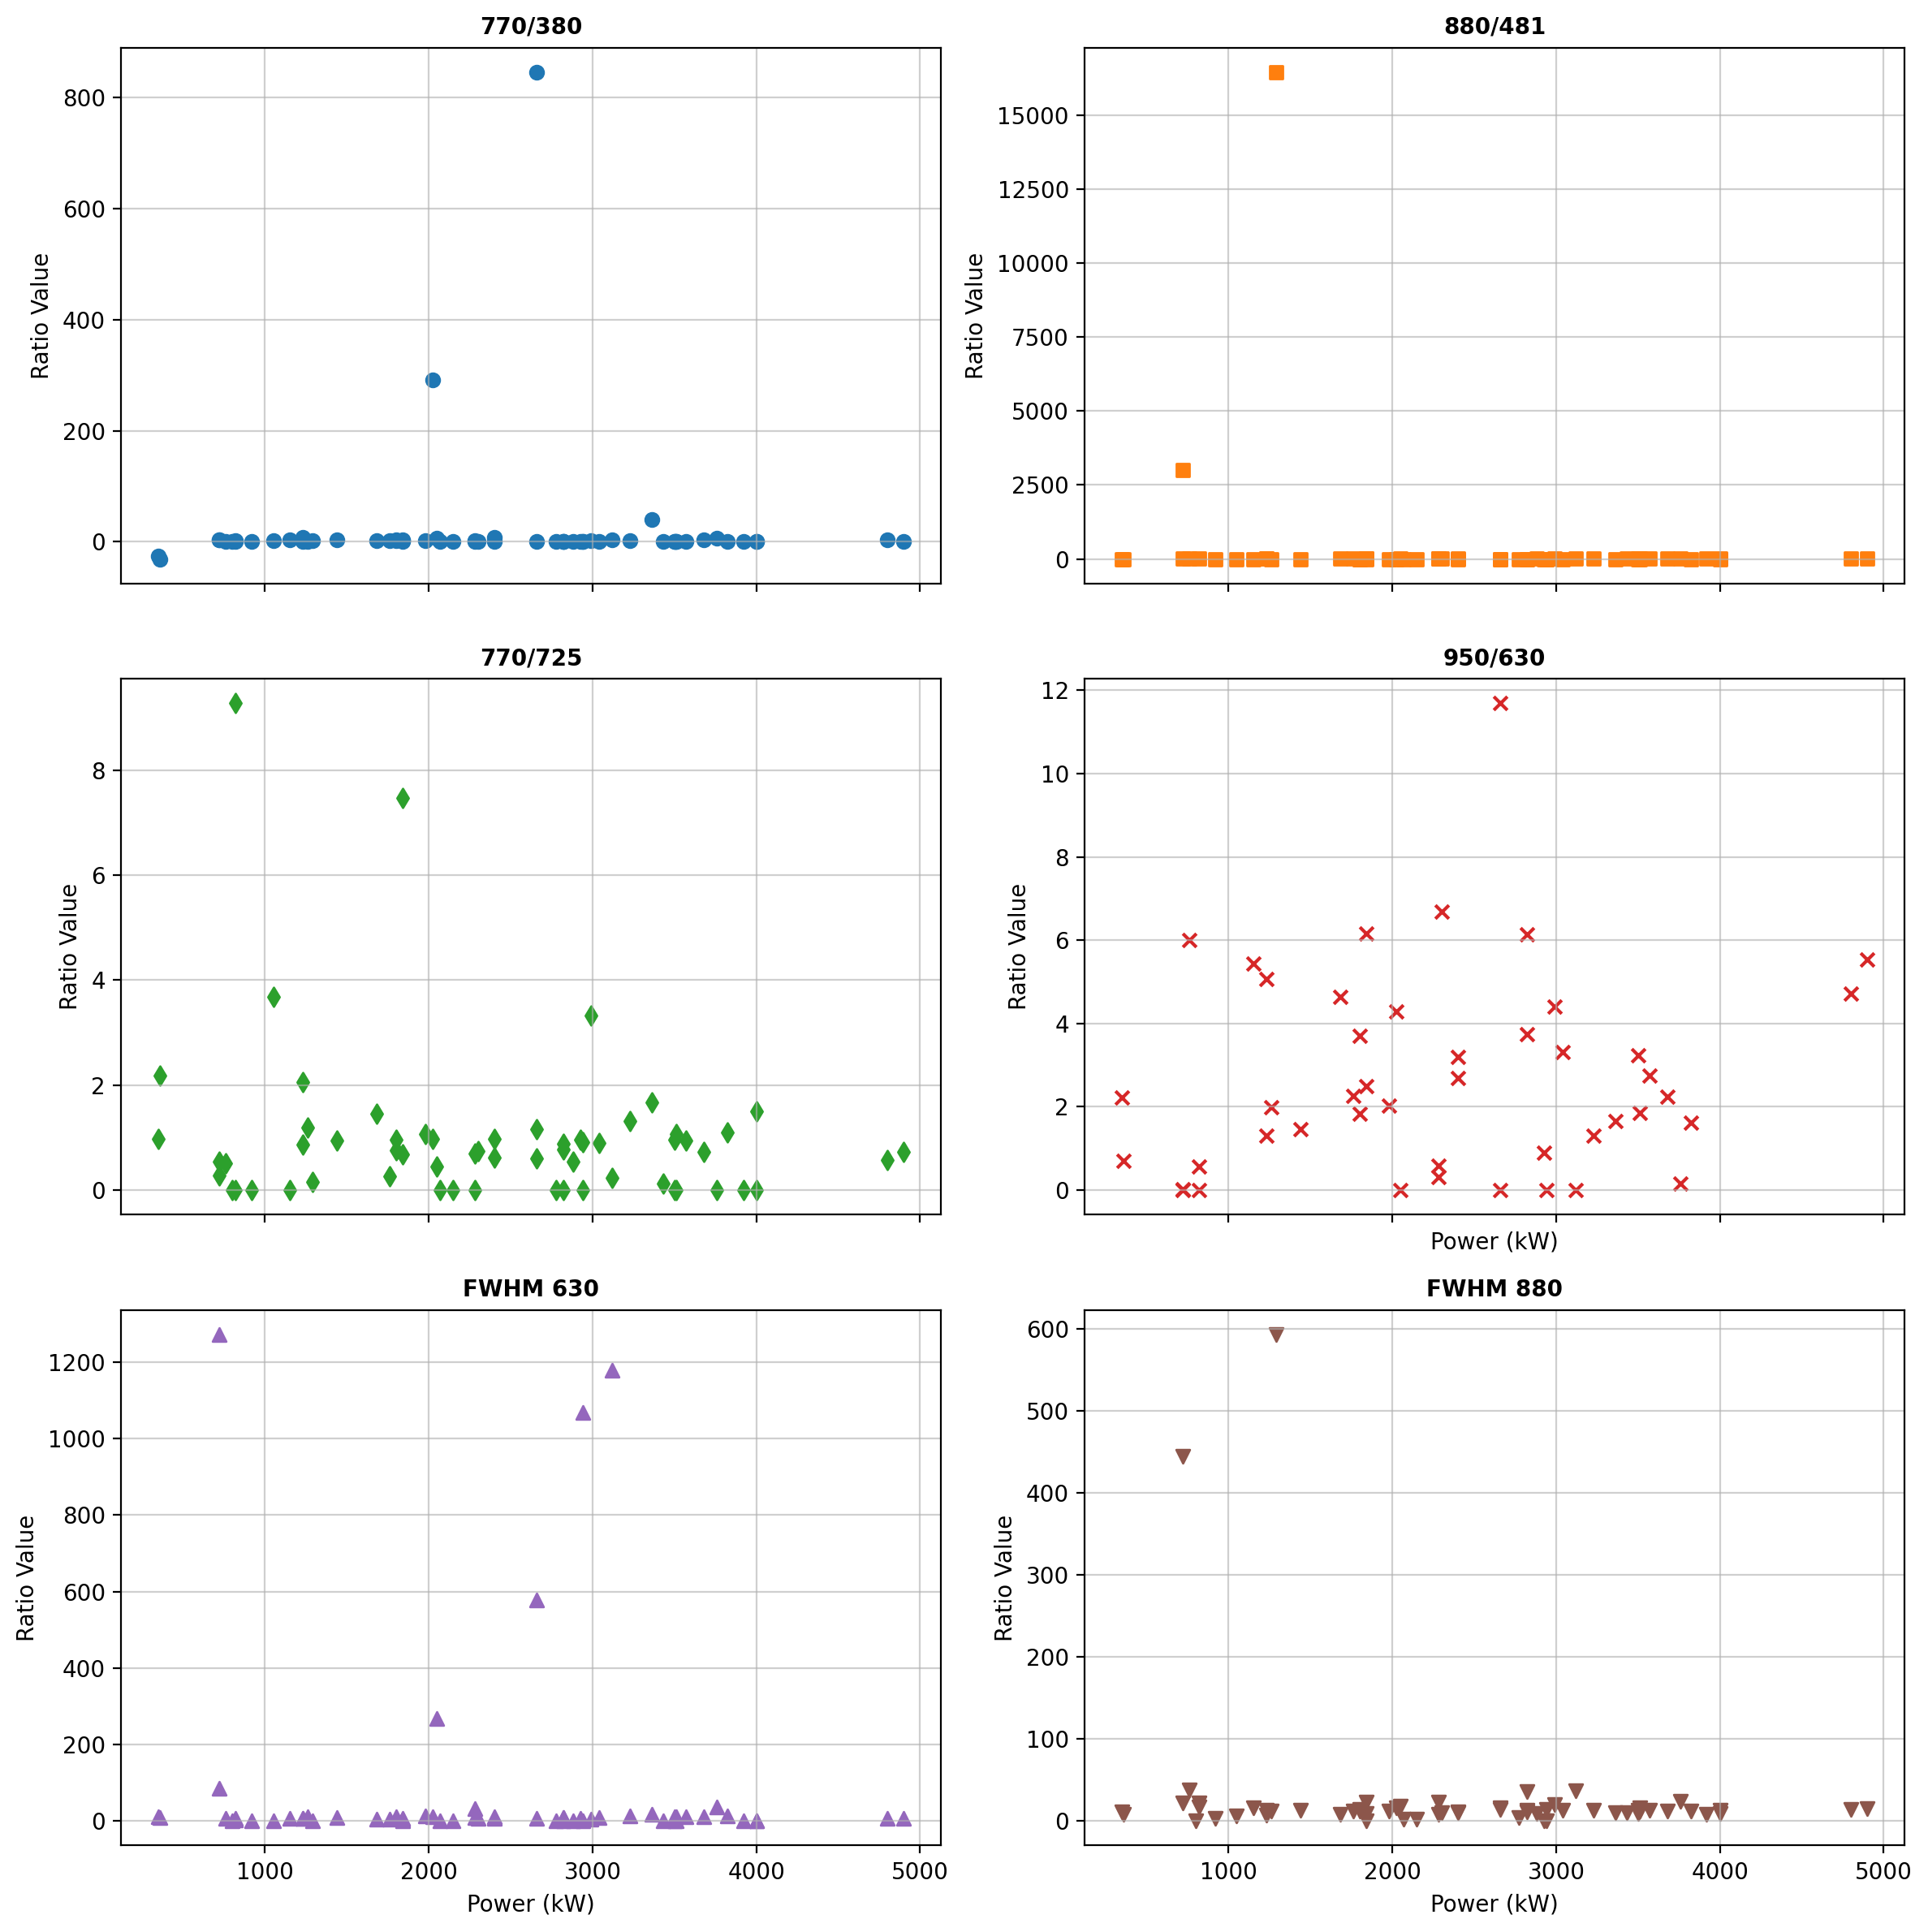

In [105]:


# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat4', 'rat5', 'w630', 'w880']
labels = ['770/380', '880/481', '770/725', '950/630', 'FWHM 630', 'FWHM 880']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Voltage_kV']*summary_df['Current_A'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Power (kW)')


plt.tight_layout()
plt.show()

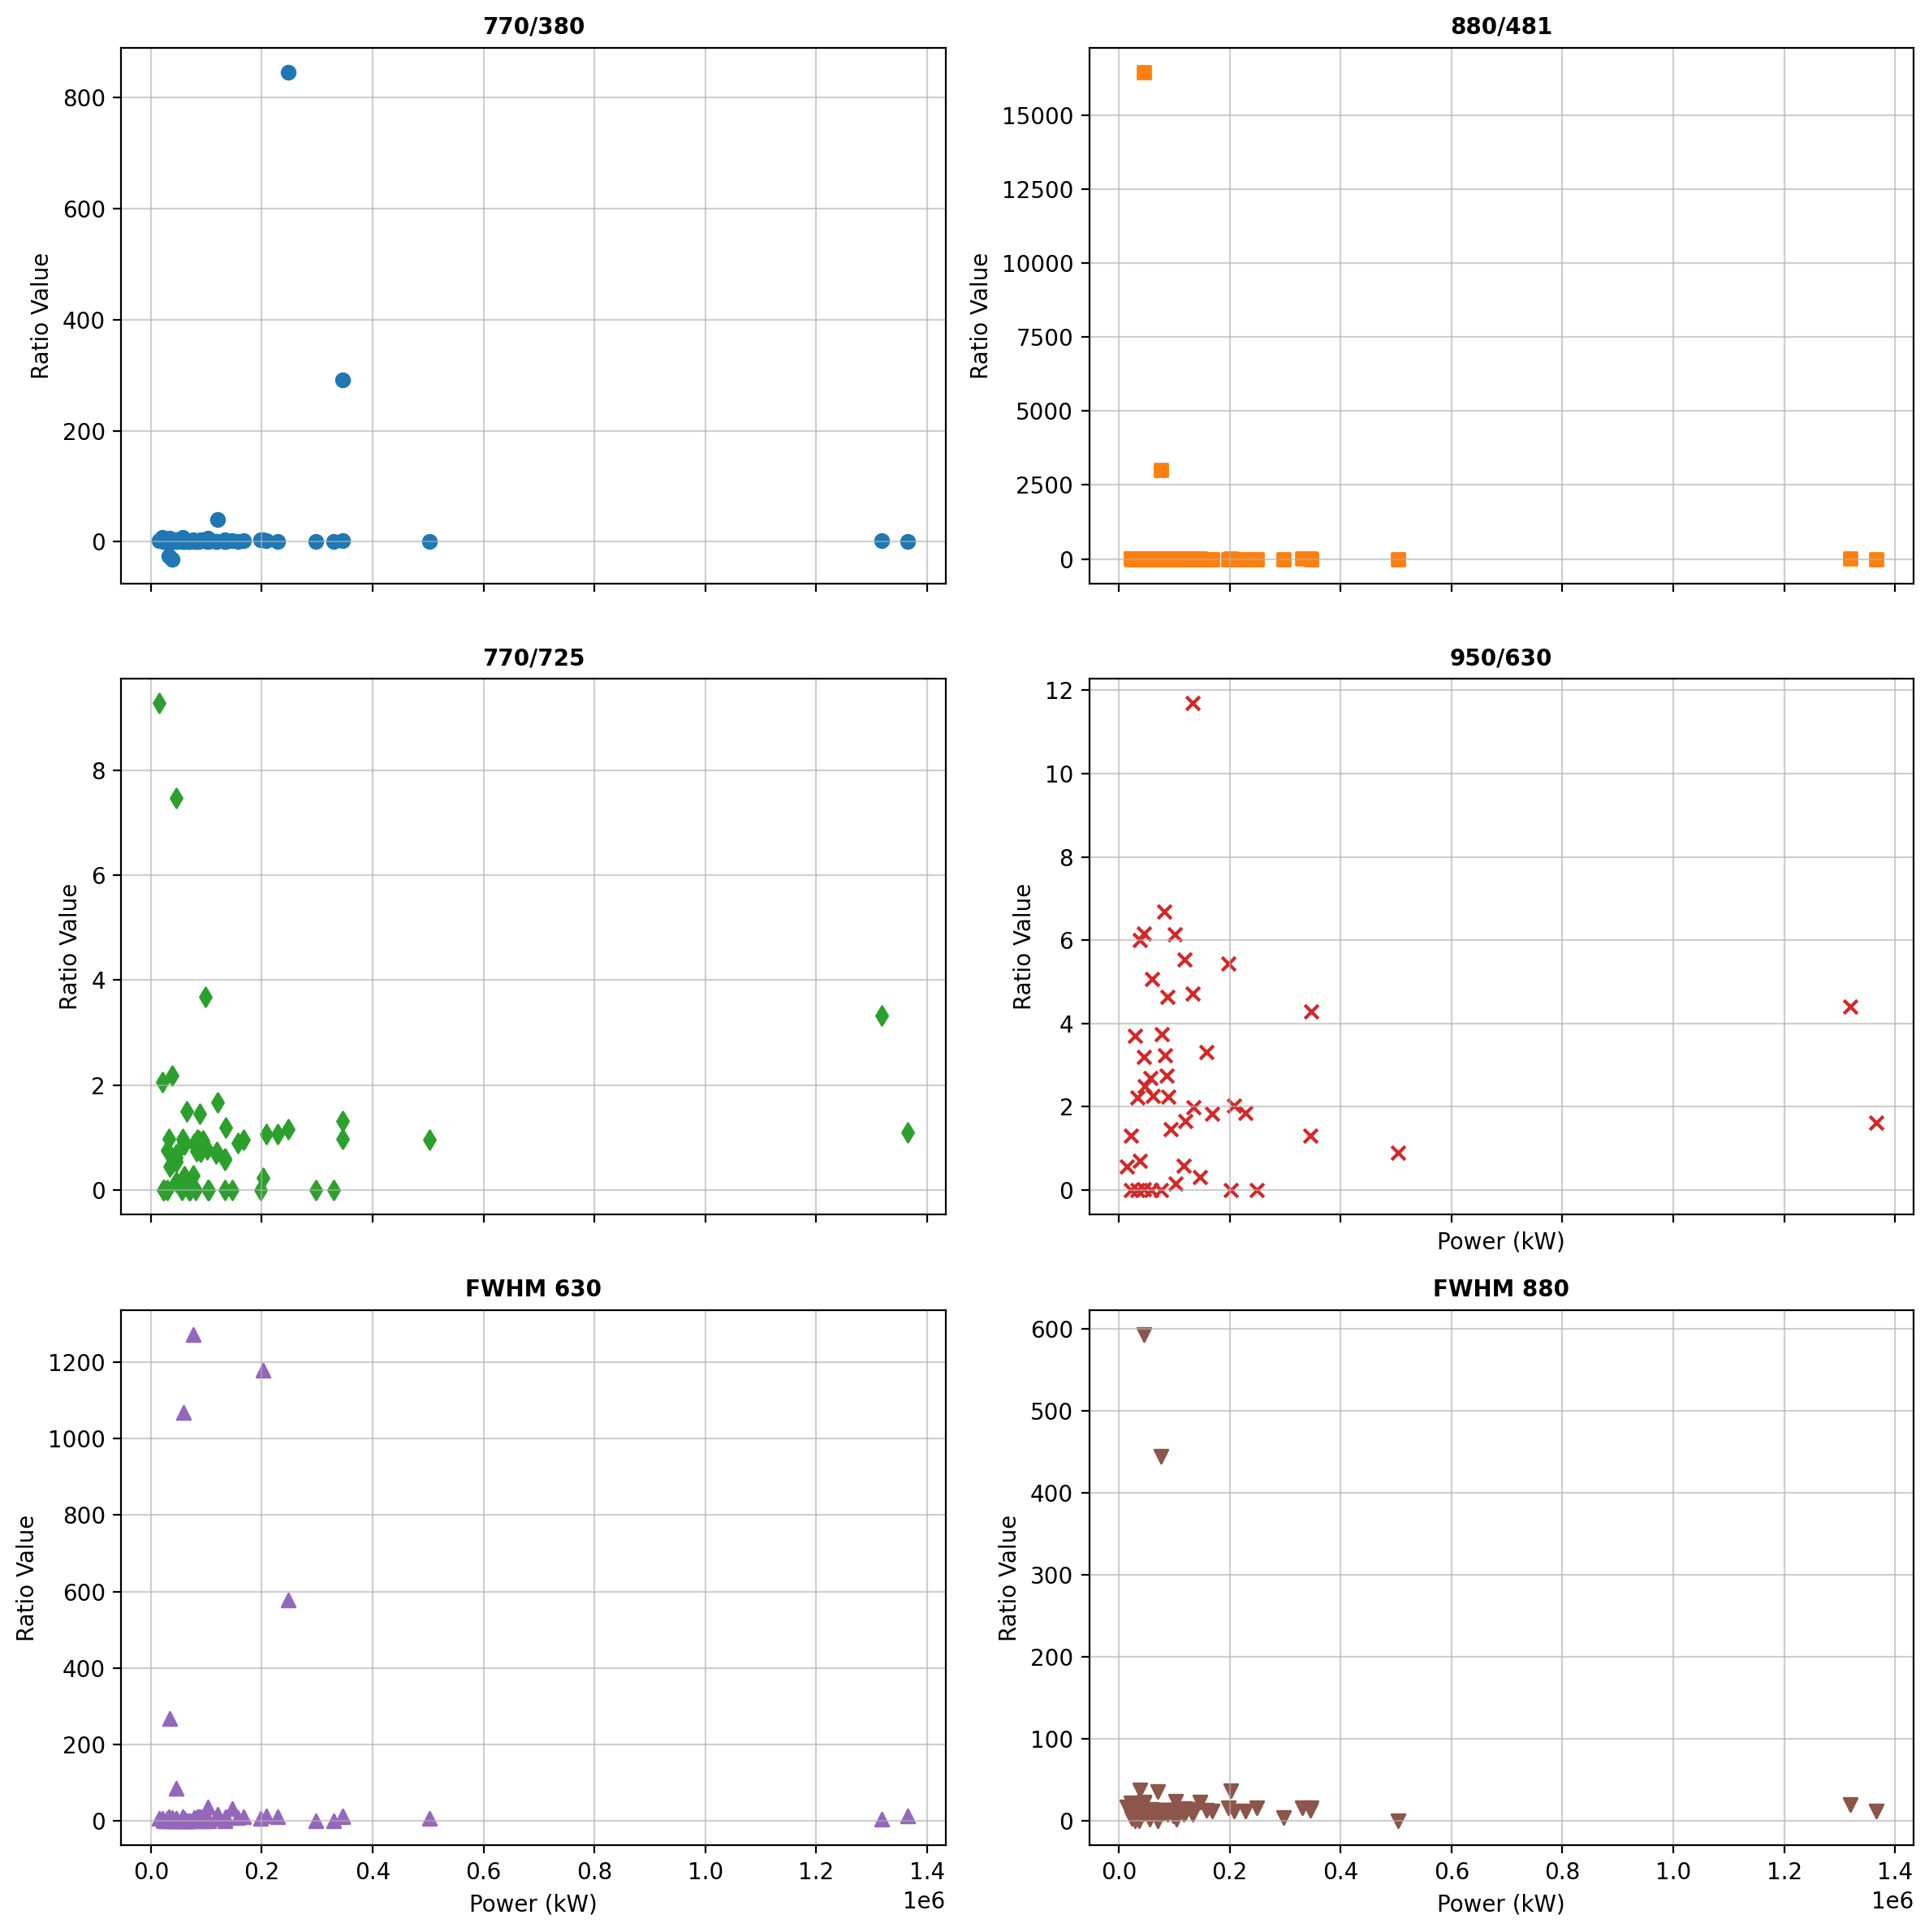

In [106]:


# 2. Define the ratios, markers, and labels for the loop
ratios = ['rat1', 'rat2', 'rat4', 'rat5', 'w630', 'w880']
labels = ['770/380', '880/481', '770/725', '950/630', 'FWHM 630', 'FWHM 880']
markers = ['o', 's', 'd', 'x', '^', 'v']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

# 3. Create the subplot array (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 12), dpi=200, sharex=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i in range(len(ratios)):
    ax = axes[i]
    ratio_col = ratios[i]
    
    # Plot the data
    ax.scatter(summary_df['Voltage_kV']*summary_df['Current_A']*summary_df['Pressure_mTorr'], summary_df[ratio_col], 
            marker=markers[i], color=colors[i], label=labels[i])
    
    # Formatting each subplot
    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_ylabel('Ratio Value')
    ax.grid(True, alpha=0.6)
    
    # Only add X-label to the bottom-most plots
    if i >= 3:
        ax.set_xlabel('Power (kW)')


plt.tight_layout()
plt.show()

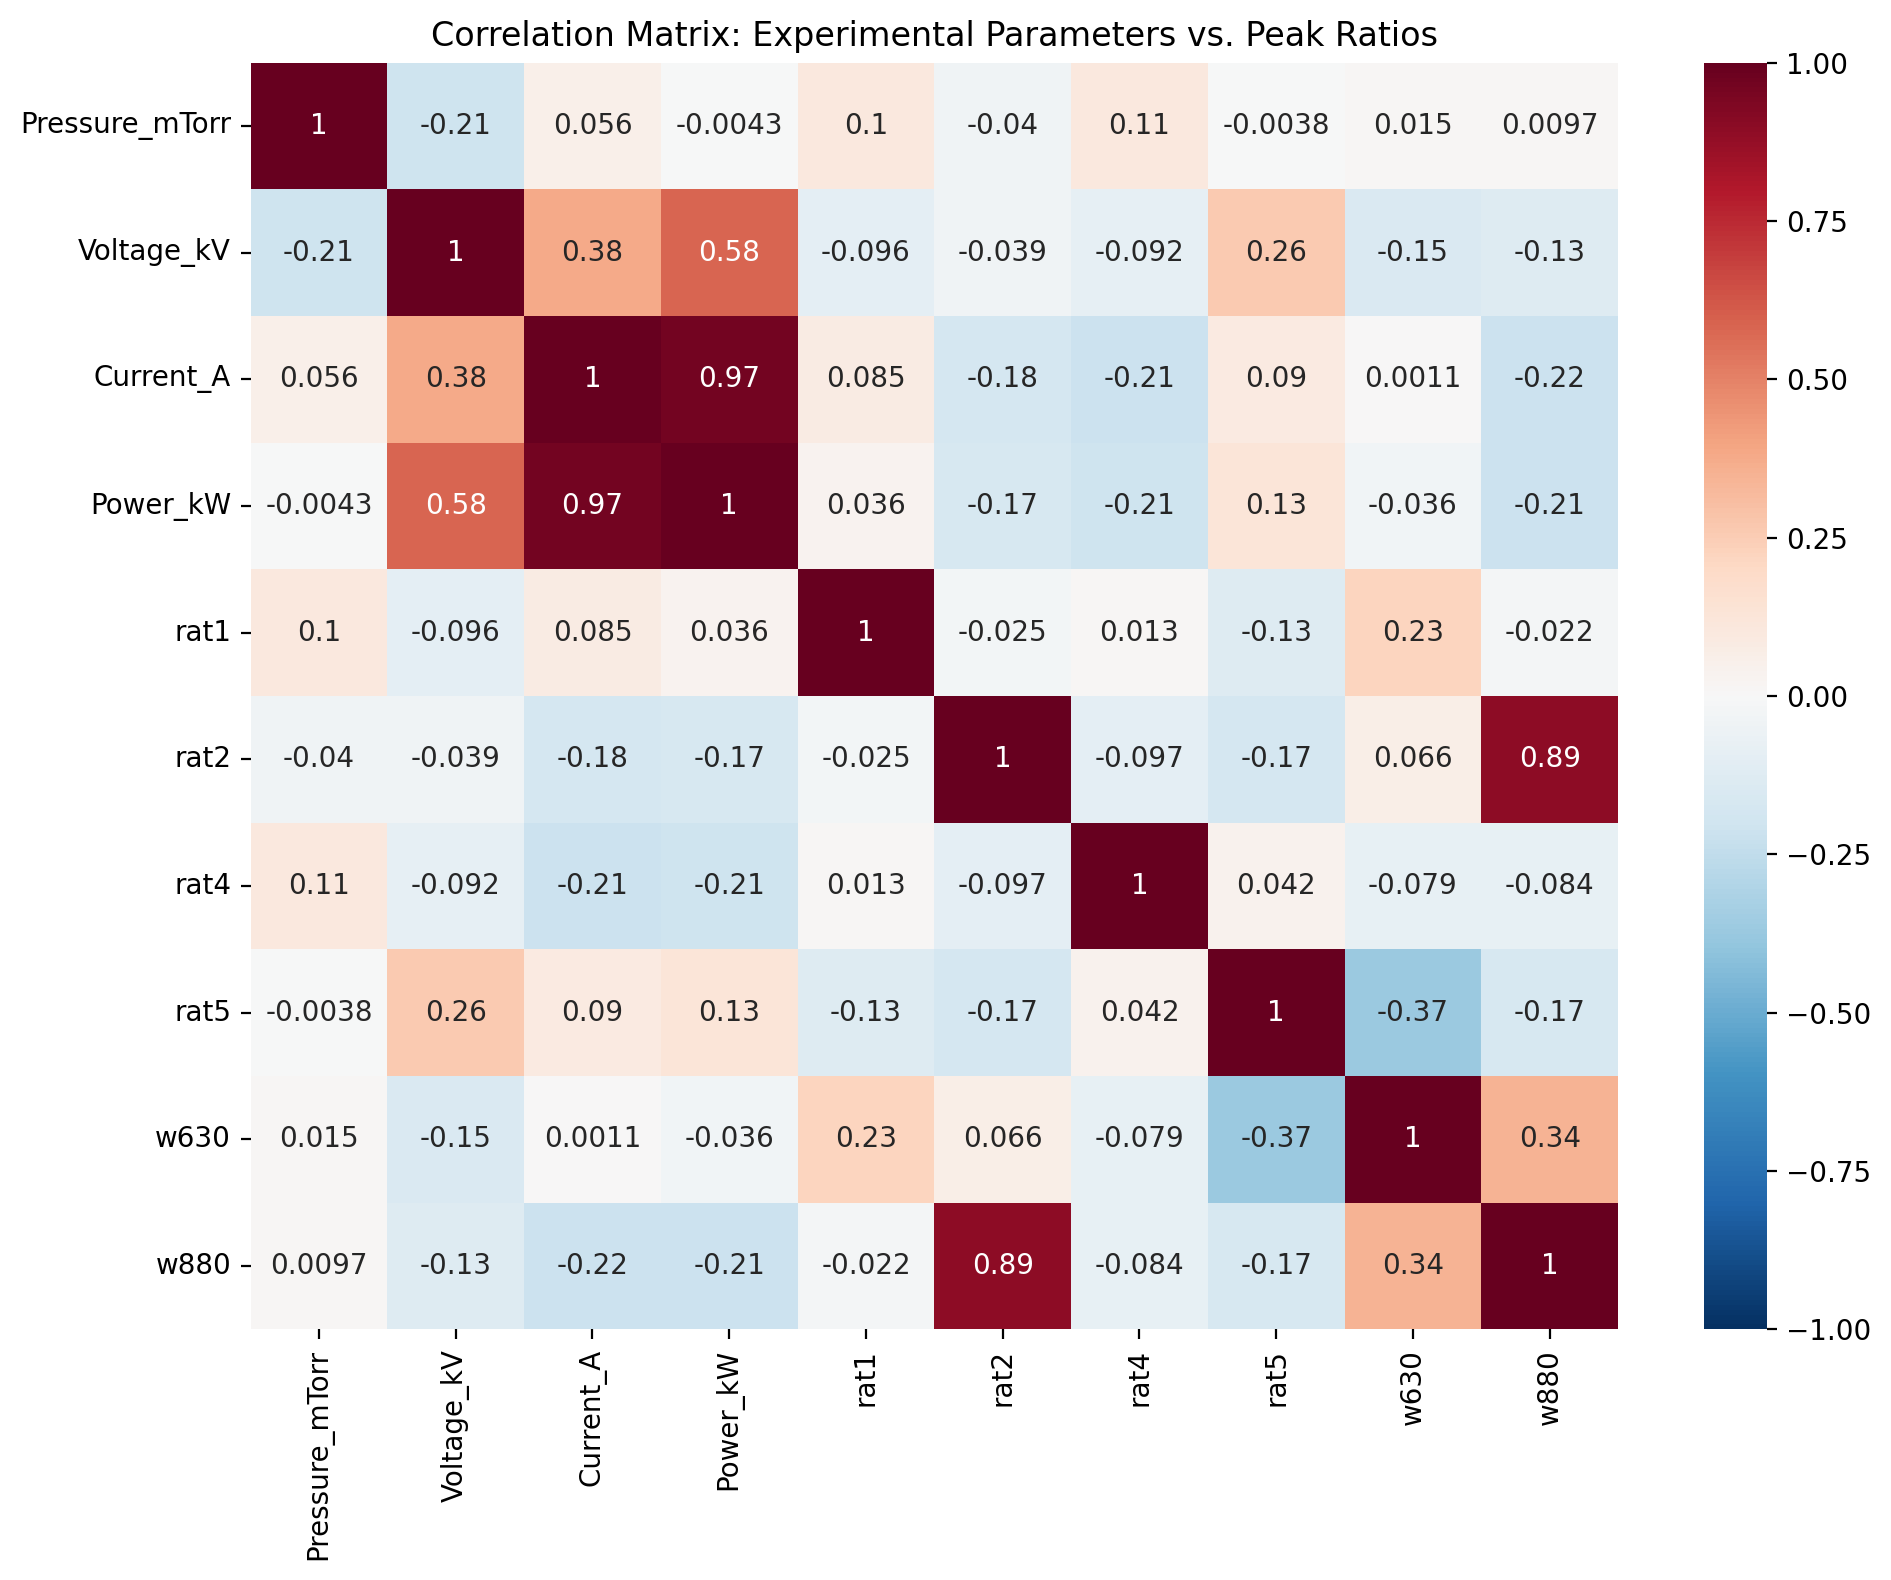

Top correlations for rat1 (770/380):
rat1              1.000000
w630              0.226175
Pressure_mTorr    0.103393
Current_A         0.084804
Power_kW          0.035804
rat4              0.013362
w880             -0.021935
rat2             -0.025113
Voltage_kV       -0.095629
rat5             -0.128248
Name: rat1, dtype: float64


In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Feature Engineering: Calculate Power
# Since you have kV and Amps, Power will be in kilo-Watts (kW)
summary_df['Power_kW'] = summary_df['Voltage_kV'] * summary_df['Current_A']

# 2. Select the variables for the matrix
# We include the inputs (Pressure, Voltage, Current, Power) and the outputs (ratios)
analysis_cols = [
    'Pressure_mTorr', 'Voltage_kV', 'Current_A', 'Power_kW',
    'rat1', 'rat2', 'rat4', 'rat5','w630','w880'
]

# 3. Calculate the Pearson Correlation Matrix
corr_matrix = summary_df[analysis_cols].corr()

# 4. Visualize with a Heatmap
plt.figure(figsize=(10, 8), dpi=200)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)

plt.title('Correlation Matrix: Experimental Parameters vs. Peak Ratios')
plt.tight_layout()
plt.show()

# 5. Print the strongest correlations for the primary ratio (rat1)
print("Top correlations for rat1 (770/380):")
print(corr_matrix['rat1'].sort_values(ascending=False))